# Proyecto Mini EDA: Catalogo De Libros

![Portadas de libros](https://images.unsplash.com/photo-1495446815901-a7297e633e8d?auto=format&fit=crop&w=1200&q=60)

El dataset protagonista combina precio, rating y disponibilidad de libros.
Objetivo: pasar de web cruda a insights claros en un flujo completo.

# Ejercicio 3 (Guiado): Mini Proyecto Scraping + EDA

Objetivo: construir un mini pipeline completo (extraccion, limpieza, analisis y exportacion).

In [1]:
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
BASE_URL = 'https://books.toscrape.com/catalogue/page-{}.html'
MAX_PAGINAS = 5
registros = []

## Paso 1: Extraccion

In [3]:
for pagina in range(1, MAX_PAGINAS + 1):
    url = BASE_URL.format(pagina)
    response = requests.get(url, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, 'html.parser')
    libros = soup.select('article.product_pod')

    for libro in libros:
        titulo = libro.h3.a.get('title', '').strip()
        precio_raw = libro.select_one('p.price_color').get_text(strip=True)
        rating_raw = libro.select_one('p.star-rating').get('class', [])
        stock = libro.select_one('p.instock.availability').get_text(' ', strip=True)

        rating = rating_raw[1] if len(rating_raw) > 1 else 'Sin rating'

        registros.append({
            'pagina': pagina,
            'titulo': titulo,
            'precio_raw': precio_raw,
            'rating': rating,
            'stock': stock
        })

    time.sleep(1)

print('Registros extraidos:', len(registros))

Registros extraidos: 100


## Paso 2: Limpieza y enriquecimiento

In [4]:
df = pd.DataFrame(registros)
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

df['precio'] = (
    df['precio_raw']
    .str.replace('£', '', regex=False)
    .str.replace('Â', '', regex=False)
    .astype(float)
)
df['rating_num'] = df['rating'].map(rating_map)
df['en_stock'] = df['stock'].str.contains('In stock', case=False, na=False)

df.head()

,pagina,titulo,precio_raw,rating,stock,precio,rating_num,en_stock
0,1,A Light in the Attic,Â£51.77,Three,In stock,51.77,3,True
1,1,Tipping the Velvet,Â£53.74,One,In stock,53.74,1,True
2,1,Soumission,Â£50.10,One,In stock,50.10,1,True
3,1,Sharp Objects,Â£47.82,Four,In stock,47.82,4,True
4,1,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,54.23,5,True


## Paso 3: Analisis guiado

In [5]:
print('Shape:', df.shape)
print('Precio medio:', round(df['precio'].mean(), 2))
print('Porcentaje en stock:', round(df['en_stock'].mean() * 100, 2), '%')

display(df.groupby('rating', as_index=False)['precio'].mean().sort_values('precio', ascending=False))

Shape: (100, 8)
Precio medio: 34.56
Porcentaje en stock: 100.0 %


,rating,precio
3,Three,36.839091
4,Two,35.909474
2,One,35.519545
1,Four,33.981667
0,Five,30.012105


## Paso 4: Visualización exploratoria del dataset

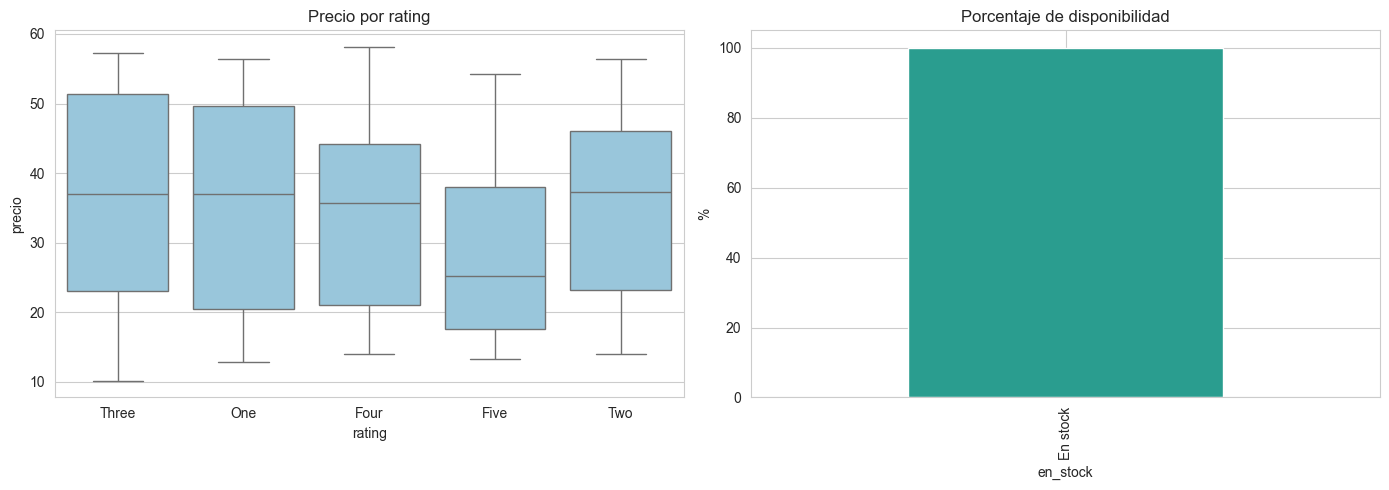

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='rating', y='precio', ax=axes[0], color='#8ecae6')
axes[0].set_title('Precio por rating')

stock_pct = df['en_stock'].value_counts(normalize=True).mul(100).rename({True: 'En stock', False: 'Sin stock'})
stock_pct.plot(kind='bar', ax=axes[1], color=['#2a9d8f', '#e63946'])
axes[1].set_title('Porcentaje de disponibilidad')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

In [7]:
df.to_csv('proyecto_scraping_libros.csv', index=False, encoding='utf-8')
print('Archivo generado: proyecto_scraping_libros.csv')

Archivo generado: proyecto_scraping_libros.csv


## Entrega
Incluye en tu entrega:
- Breve descripcion del proceso de extraccion
- 3 hallazgos (insights)
- 2 limites del scraping aplicado
- CSV final exportado